# Cleaned-feature Bayesian Network with Hill Climb Structure Learning

This notebook is a copy of `bayesian-network-raw-hill-climb.ipynb` that adds a full data-cleaning stage informed by the source paper (`description.pdf`, Strack et al., *BioMed Research International*, 2014) before structure and parameter learning.

**What changed compared to the raw-feature notebook:**

- A dedicated **Data Cleaning** section reproduces the preprocessing described in the paper's *Section 2.3* (dropping sparse/irrelevant columns, one encounter per patient, removing hospice/death discharges, ICD-9 diagnosis grouping, ID-to-label mapping, age bucketing).
- The Bayesian Network is trained directly with the **best hyperparameter configuration** found by the exhaustive grid search in the raw-feature notebook (`top12_k2_parents3_cat8_bins4`: 12 features, K2 score, max in-degree 3, category cap 8, 4 numeric bins) instead of repeating the full 24-run grid search.
- A dedicated **Data Cleaning Notes** markdown cell documents every transformation and the reasoning behind it, including a sanity check against the row/percentage counts reported in the paper.

The end-to-end workflow is otherwise unchanged: split train/validation/test before learning any preprocessing parameter, rank raw (now cleaned) features by mutual information, discretize into a bounded number of categories, learn structure with hill climbing, fit BDeu-smoothed CPDs, and report held-out test metrics.

## Setup

Run this notebook top to bottom, in Colab or locally. The code avoids data leakage: cleaning decisions that require statistics (e.g. category caps, numeric bin edges) are learned from the training split only. Plain rule-based cleaning (ID→label maps, ICD-9 grouping, dropping known-sparse columns) is applied before the split because it uses fixed, paper-documented rules rather than any statistic estimated from the data.

In [1]:
%pip install -q "pgmpy>=0.1.26" "scikit-learn>=1.4" "networkx>=3.0" "joblib>=1.3" "gdown>=5.0"

Note: you may need to restart the kernel to use updated packages.


In [2]:
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    log_loss,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, label_binarize
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import normalized_mutual_info_score

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 120)

RANDOM_STATE = 42
TARGET = "readmitted"
ID_COLUMNS = ["encounter_id", "patient_nbr"]

## Load Raw Data

Uses the same Google Drive file as the other notebooks. If a local copy of `diabetic_data.csv` is available (e.g. running this notebook from a clone of the project repository), it is used directly and no download is needed.

In [3]:
CANDIDATE_LOCAL_PATHS = [
    Path("../diabetic_data.csv"),
    Path("diabetic_data.csv"),
    Path("/content/data/diabetic_data.csv"),
]
DRIVE_URL = "https://drive.google.com/file/d/1qtACu4wjaIRsYp9bfYZs7uMvVkdyiqEw/view?usp=sharing"

DATA_PATH = next((p for p in CANDIDATE_LOCAL_PATHS if p.exists()), None)

if DATA_PATH is None:
    import gdown

    DATA_DIR = Path("/content/data")
    DATA_DIR.mkdir(parents=True, exist_ok=True)
    DATA_PATH = DATA_DIR / "diabetic_data.csv"
    gdown.download(DRIVE_URL, str(DATA_PATH), quiet=False, fuzzy=True)
else:
    print(f"Using local file: {DATA_PATH}")

df_raw = pd.read_csv(DATA_PATH)
print(df_raw.shape)
display(df_raw.head())
display(df_raw[TARGET].value_counts(normalize=True).rename("class_rate"))

Using local file: ../diabetic_data.csv


(101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,?,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,?,?,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,?,?,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,?,?,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,?,?,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,?,?,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


readmitted
NO     0.539119
>30    0.349282
<30    0.111599
Name: class_rate, dtype: float64

## Data Cleaning

The raw extract has 101,766 encounters and several well-known data-quality issues that the original study (`description.pdf`, Section 2.3) documents in detail:

- `weight` is missing in 97% of rows and `payer_code` in about 40–52% of rows (values are literally the string `"?"`, not `NaN`).
- `admission_type_id`, `discharge_disposition_id`, and `admission_source_id` are **numeric codes** that stand for categorical concepts (e.g. `1` = *Emergency*), so leaving them as integers risks the model treating them as ordered/continuous.
- The same patient can appear multiple times; the study restricts the analysis to one (the first) encounter per patient to satisfy the independence assumption of their statistical model. We keep that restriction for the same reason: repeated visits from the same patient are correlated and would otherwise bias any model, including a Bayesian Network.
- Encounters that ended in a hospice discharge or in-hospital death are excluded, because these outcomes cannot be "readmitted" and would bias the target distribution.
- `diag_1`, `diag_2`, and `diag_3` store raw ICD-9 codes (up to ~950 distinct values each). The study groups them into 9 clinically meaningful categories (Table 2) instead of using the raw codes directly.

Each step below is implemented as its own cell so the effect can be inspected incrementally. A full written summary is provided afterwards in **Data Cleaning Notes**.

### Step 1 — Normalize literal `"?"` into real missing values

The raw CSV encodes missing data as the string `"?"` instead of an empty cell. Converting it to a proper `NaN` lets every later `pandas` missing-value check (`isna`, `fillna`, `dropna`) work correctly, and lets us measure missingness the same way the paper does.

In [4]:
df_clean = df_raw.replace("?", np.nan)

missing_share = (df_clean.isna().mean() * 100).sort_values(ascending=False)
print("Columns with missing values after normalizing '?' (top 10):")
display(missing_share[missing_share > 0].head(10).round(1).rename("% missing"))

Columns with missing values after normalizing '?' (top 10):


weight               96.9
max_glu_serum        94.7
A1Cresult            83.3
medical_specialty    49.1
payer_code           39.6
race                  2.2
diag_3                1.4
diag_2                0.4
diag_1                0.0
Name: % missing, dtype: float64

### Step 2 — Drop the two columns that are too sparse or not relevant, per the paper

The paper explicitly removes `weight` ("too sparse", 97% missing) and `payer_code` ("high percentage of missing values ... not considered relevant to the outcome"). `medical_specialty` is also heavily missing (~49%) but the paper keeps it and adds an explicit "missing" category instead of dropping it, since it can still carry information about which department treated the patient. We follow the same three decisions.

In [5]:
df_clean = df_clean.drop(columns=["weight", "payer_code"])

df_clean["medical_specialty"] = df_clean["medical_specialty"].fillna("Missing")
df_clean["race"] = df_clean["race"].fillna("Missing")

# 3 rows have gender == "Unknown/Invalid" -- not a usable category, and negligible in volume.
rows_before = len(df_clean)
df_clean = df_clean[df_clean["gender"] != "Unknown/Invalid"]
print(f"Dropped {rows_before - len(df_clean)} rows with unusable gender value.")

Dropped 3 rows with unusable gender value.


### Step 3 — Map coded IDs to readable categories, and drop encounters ending in hospice/death

`admission_type_id`, `discharge_disposition_id`, and `admission_source_id` are integer foreign keys into the dataset's official `IDS_mapping.csv` lookup tables. Replacing the codes with their text labels avoids the model implicitly assuming, e.g., that admission type `4` is "between" types `3` and `5`.

While mapping `discharge_disposition_id`, we also drop encounters that ended in **expired** or **hospice** discharge (codes `11, 13, 14, 19, 20, 21`). These patients cannot be "readmitted" by definition, and the paper removes them for exactly this reason ("we removed all encounters that resulted in either discharge to a hospice or patient death, to avoid biasing our analysis").

In [6]:
ADMISSION_TYPE_MAP = {
    1: "Emergency", 2: "Urgent", 3: "Elective", 4: "Newborn",
    5: "Not Available", 6: "Not Available", 7: "Trauma Center", 8: "Not Available",
}

DISCHARGE_DISPOSITION_MAP = {
    1: "Discharged to home", 2: "Transferred to another hospital", 3: "Transferred to SNF",
    4: "Transferred to ICF", 5: "Transferred to other inpatient care", 6: "Home with home health service",
    7: "Left against medical advice", 8: "Home under IV provider care", 9: "Admitted as inpatient (same hospital)",
    10: "Neonate transferred for aftercare", 11: "Expired", 12: "Still patient / expected back",
    13: "Hospice / home", 14: "Hospice / medical facility", 15: "Transferred to Medicare swing bed",
    16: "Transferred/referred for outpatient services", 17: "Transferred/referred for outpatient services",
    18: "Not Available", 19: "Expired at home (Medicaid hospice)", 20: "Expired in medical facility (Medicaid hospice)",
    21: "Expired, place unknown (Medicaid hospice)", 22: "Transferred to rehab facility",
    23: "Transferred to long term care hospital", 24: "Transferred to nursing facility (Medicaid only)",
    25: "Not Available", 26: "Not Available", 27: "Transferred to federal health care facility",
    28: "Transferred to psychiatric hospital", 29: "Transferred to critical access hospital",
    30: "Transferred to other health care institution",
}

ADMISSION_SOURCE_MAP = {
    1: "Physician referral", 2: "Clinic referral", 3: "HMO referral", 4: "Transfer from hospital",
    5: "Transfer from SNF", 6: "Transfer from other health facility", 7: "Emergency room",
    8: "Court/law enforcement", 9: "Not Available", 10: "Transfer from critical access hospital",
    11: "Normal delivery", 12: "Premature delivery", 13: "Sick baby", 14: "Extramural birth",
    15: "Not Available", 17: "Not Available", 18: "Transfer from another home health agency",
    19: "Readmission to same home health agency", 20: "Not Available", 21: "Not Available",
    22: "Transfer from hospital inpatient (same facility)", 23: "Born inside this hospital",
    24: "Born outside this hospital", 25: "Transfer from ambulatory surgery center", 26: "Transfer from hospice",
}

# Codes for in-hospital death or hospice discharge (cannot be readmitted -> excluded, per paper Sec. 2.3).
EXPIRED_OR_HOSPICE_CODES = {11, 13, 14, 19, 20, 21}

rows_before = len(df_clean)
df_clean = df_clean[~df_clean["discharge_disposition_id"].isin(EXPIRED_OR_HOSPICE_CODES)]
print(f"Dropped {rows_before - len(df_clean)} encounters that ended in death or hospice discharge.")

df_clean["admission_type"] = df_clean["admission_type_id"].map(ADMISSION_TYPE_MAP).fillna("Not Available")
df_clean["discharge_disposition"] = df_clean["discharge_disposition_id"].map(DISCHARGE_DISPOSITION_MAP).fillna("Not Available")
df_clean["admission_source"] = df_clean["admission_source_id"].map(ADMISSION_SOURCE_MAP).fillna("Not Available")

df_clean = df_clean.drop(columns=["admission_type_id", "discharge_disposition_id", "admission_source_id"])

display(df_clean[["admission_type", "discharge_disposition", "admission_source"]].head())

Dropped 2423 encounters that ended in death or hospice discharge.


,admission_type,discharge_disposition,admission_source
0,Not Available,Not Available,Physician referral
1,Emergency,Discharged to home,Emergency room
2,Emergency,Discharged to home,Emergency room
3,Emergency,Discharged to home,Emergency room
4,Emergency,Discharged to home,Emergency room


### Step 4 — Keep only the first encounter per patient

Several patients have multiple inpatient stays in the dataset. Treating every row as an independent observation (as a Bayesian Network's likelihood implicitly does) would let repeat patients dominate the learned probabilities and would leak information about a patient's future encounters into the model. The paper handles this the same way: *"we used only one encounter per patient; in particular, we considered only the first encounter for each patient."* We approximate "first" by the smallest `encounter_id`, which increases monotonically with time in this dataset.

In [7]:
rows_before = len(df_clean)
df_clean = (
    df_clean.sort_values("encounter_id")
    .drop_duplicates(subset="patient_nbr", keep="first")
    .reset_index(drop=True)
)
print(f"Rows before: {rows_before:,} -> rows after keeping first encounter per patient: {len(df_clean):,}")
print("Paper reports 69,984 encounters after the equivalent cleaning steps; "
      f"this notebook reaches {len(df_clean):,}, a difference of "
      f"{abs(len(df_clean) - 69_984)} rows (likely due to small tie-breaking differences in "
      "the exact hospice/death code list or encounter ordering).")

Rows before: 99,340 -> rows after keeping first encounter per patient: 69,987
Paper reports 69,984 encounters after the equivalent cleaning steps; this notebook reaches 69,987, a difference of 3 rows (likely due to small tie-breaking differences in the exact hospice/death code list or encounter ordering).


### Step 5 — Group ICD-9 diagnosis codes into clinical categories

`diag_1`, `diag_2`, and `diag_3` store raw ICD-9-CM codes: hundreds of distinct string values (e.g. `"250.83"`, `"V27"`, `"E878"`) that are far too sparse to use directly in a discrete Bayesian Network — most codes would appear only a handful of times. The paper groups the primary diagnosis into 9 categories (Table 2): Circulatory, Respiratory, Digestive, Diabetes, Injury, Musculoskeletal, Genitourinary, Neoplasms, and Other. We apply the same grouping rule to all three diagnosis columns and drop the original high-cardinality codes.

In [8]:
def classify_diag(code):
    """Group an ICD-9-CM code into the clinical categories used by the paper (Table 2)."""
    if pd.isna(code):
        return "Missing"
    code = str(code)
    if code.startswith("250"):
        return "Diabetes"
    if code.startswith(("V", "E")):
        return "Other"
    try:
        value = float(code)
    except ValueError:
        return "Other"
    if 390 <= value <= 459 or value == 785:
        return "Circulatory"
    if 460 <= value <= 519 or value == 786:
        return "Respiratory"
    if 520 <= value <= 579 or value == 787:
        return "Digestive"
    if 800 <= value <= 999:
        return "Injury"
    if 710 <= value <= 739:
        return "Musculoskeletal"
    if 580 <= value <= 629 or value == 788:
        return "Genitourinary"
    if 140 <= value <= 239:
        return "Neoplasms"
    return "Other"


for col in ["diag_1", "diag_2", "diag_3"]:
    df_clean[f"{col}_group"] = df_clean[col].apply(classify_diag)

df_clean = df_clean.drop(columns=["diag_1", "diag_2", "diag_3"])

primary_diag_share = (df_clean["diag_1_group"].value_counts(normalize=True) * 100).round(1)
print("Primary diagnosis category shares (compare with paper Table 2):")
display(primary_diag_share)

Primary diagnosis category shares (compare with paper Table 2):


diag_1_group
Circulatory        30.6
Other              17.3
Respiratory        13.6
Digestive           9.3
Diabetes            8.2
Injury              6.7
Musculoskeletal     5.8
Genitourinary       4.9
Neoplasms           3.6
Missing             0.0
Name: proportion, dtype: float64

### Step 6 — Bucket age into the three groups motivated by the paper's own analysis

The paper's Figure 2 shows the logit of the readmission rate against the 10-year age bins and finds three visually distinct regimes: under 30, 30–60, and over 60. It uses that finding to collapse the `age` column into three groups for the regression model (Table 3). We do the same for the Bayesian Network: it both matches the paper's own feature engineering and reduces `age`'s cardinality, which helps keep its conditional probability tables well-populated. The finer-grained original `age` column is dropped in favor of this bucketed version to avoid the two carrying almost the same information.

In [9]:
AGE_GROUP_MAP = {
    "[0-10)": "<30", "[10-20)": "<30", "[20-30)": "<30",
    "[30-40)": "30-60", "[40-50)": "30-60", "[50-60)": "30-60",
    "[60-70)": ">60", "[70-80)": ">60", "[80-90)": ">60", "[90-100)": ">60",
}

df_clean["age_group"] = df_clean["age"].map(AGE_GROUP_MAP)
df_clean = df_clean.drop(columns=["age"])

age_share = (df_clean["age_group"].value_counts(normalize=True) * 100).round(1)
print("Age group shares (compare with paper Table 3: 2.6% / 31.3% / 66.2%):")
display(age_share)

Age group shares (compare with paper Table 3: 2.6% / 31.3% / 66.2%):


age_group
>60      66.2
30-60    31.3
<30       2.6
Name: proportion, dtype: float64

### Step 7 — Final cleanup: lab-result labels and constant columns

`max_glu_serum` and `A1Cresult` use `NaN` to mean "test not taken", which is itself informative (the paper's whole analysis centers on how rarely `A1Cresult` is measured). We replace it with an explicit `"Not tested"` category instead of dropping or imputing it. Finally, some medication columns are constant (a single value for every remaining row) once the dataset has been filtered down — these carry no information for structure learning and are dropped, the same way the raw-feature notebook drops constant columns dynamically after its own train split.

In [10]:
df_clean["max_glu_serum"] = df_clean["max_glu_serum"].fillna("Not tested")
df_clean["A1Cresult"] = df_clean["A1Cresult"].fillna("Not tested")

constant_columns = [
    col for col in df_clean.columns
    if col not in ID_COLUMNS + [TARGET] and df_clean[col].nunique(dropna=False) <= 1
]
df_clean = df_clean.drop(columns=constant_columns)
print("Dropped constant columns:", constant_columns)

print(f"\nCleaned dataset shape: {df_clean.shape[0]:,} rows x {df_clean.shape[1]} columns")
print(f"Remaining missing values: {int(df_clean.isna().sum().sum())}")
display(df_clean[TARGET].value_counts(normalize=True).rename("class_rate"))

Dropped constant columns: ['examide', 'citoglipton', 'glimepiride-pioglitazone']

Cleaned dataset shape: 69,987 rows x 45 columns


Remaining missing values: 0


readmitted
NO     0.592624
>30    0.317573
<30    0.089802
Name: class_rate, dtype: float64

## Data Cleaning Notes — Summary

This section documents, in one place, exactly what was done to the raw 101,766-row extract and why, so the reasoning can be presented without re-reading every code cell above.

1. **Normalized missing-value markers.** The raw CSV uses the literal string `"?"` for missing values instead of empty cells. It was replaced with a real `NaN` so that every later missing-value check behaves correctly and missingness percentages are comparable to the ones reported in the paper's Table 1.
2. **Dropped `weight`** (≈97% missing) and **`payer_code`** (≈40–52% missing) exactly as the paper does, because both are too sparse and the paper found `payer_code` not relevant to the outcome. `medical_specialty` (≈49% missing) was **kept**, with missing values recoded as an explicit `"Missing"` category, following the paper's approach of retaining it rather than dropping it.
3. **Removed 3 rows** with `gender == "Unknown/Invalid"` — not a usable demographic category and a negligible fraction of the data.
4. **Mapped numeric ID columns to text labels.** `admission_type_id`, `discharge_disposition_id`, and `admission_source_id` are categorical codes disguised as integers (per the official `IDS_mapping.csv` lookup). Leaving them numeric risks the model (and any downstream numeric binning) treating unrelated categories as ordered. They were replaced with human-readable text and the original `_id` columns dropped.
5. **Removed encounters that ended in death or hospice discharge** (`discharge_disposition_id` in `{11, 13, 14, 19, 20, 21}`), because these patients cannot be readmitted and would otherwise bias the class distribution and any learned relationship with the target. This mirrors the paper's Section 2.3.
6. **Kept only the first encounter per patient** (smallest `encounter_id`, used as a proxy for chronological order), matching the paper's independence-of-observations assumption. Together with step 5, this took the dataset from 101,766 rows down to the number reported below — very close to the paper's reported 69,984 encounters, which is a good sanity check that the cleaning logic matches the original methodology.
7. **Grouped `diag_1`, `diag_2`, and `diag_3` ICD-9 codes into 9 clinical categories** (Circulatory, Respiratory, Digestive, Diabetes, Injury, Musculoskeletal, Genitourinary, Neoplasms, Other/Missing) using the same code ranges as the paper's Table 2, instead of keeping ~700–950 raw ICD-9 codes per column. The raw diagnosis columns were dropped in favor of the grouped versions. This is the single biggest cardinality reduction in the cleaning stage and is essential for a discrete Bayesian Network, whose conditional probability tables grow combinatorially with the number of states per node.
8. **Bucketed `age` into 3 groups** (`<30`, `30-60`, `>60`) based on the distinct regimes the paper identifies in Figure 2, and dropped the original 10-year-bin `age` column so the network does not carry two highly redundant encodings of the same variable.
9. **Recoded `max_glu_serum` / `A1Cresult` missing values as `"Not tested"`** — the absence of these lab tests is itself clinically meaningful (it is literally what the paper's whole analysis is about), so it is kept as an explicit category rather than imputed or dropped.
10. **Dropped columns that became constant** after the row filtering above (medication columns that end up with a single value for every remaining encounter), since they cannot inform structure learning.

**What was intentionally left unchanged:** the 23 individual medication columns (`metformin`, `insulin`, etc.), `race`, `gender`, numeric utilization counts (`num_lab_procedures`, `num_medications`, `number_outpatient`/`emergency`/`inpatient`, `number_diagnoses`, `time_in_hospital`), and the 3-class `readmitted` target are kept as in the raw-feature notebook. They already have a small, well-defined number of states (or are handled later by the same quantile-binning logic used for raw numeric columns) and did not need paper-specific cleaning.

In [11]:
print(f"Final cleaned shape: {df_clean.shape[0]:,} rows x {df_clean.shape[1]} columns")
print(f"Paper's reference figure: 69,984 rows after the analogous cleaning steps.")
display(df_clean.head())

Final cleaned shape: 69,987 rows x 45 columns
Paper's reference figure: 69,984 rows after the analogous cleaning steps.


,encounter_id,patient_nbr,race,gender,time_in_hospital,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,insulin,glyburide-metformin,glipizide-metformin,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,admission_type,discharge_disposition,admission_source,diag_1_group,diag_2_group,diag_3_group,age_group
0,12522,48330783,Caucasian,Female,13,Missing,68,2,28,0,0,0,8,Not tested,Not tested,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,Steady,No,No,No,No,Ch,Yes,NO,Urgent,Discharged to home,Transfer from hospital,Circulatory,Circulatory,Other,>60
1,15738,63555939,Caucasian,Female,12,InternalMedicine,33,3,18,0,0,0,8,Not tested,Not tested,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,Steady,No,No,No,No,Ch,Yes,NO,Elective,Transferred to SNF,Transfer from hospital,Circulatory,Neoplasms,Respiratory,>60
2,16680,42519267,Caucasian,Male,1,Missing,51,0,8,0,0,0,5,Not tested,Not tested,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,Steady,No,No,No,No,Ch,Yes,NO,Emergency,Discharged to home,Emergency room,Neoplasms,Neoplasms,Diabetes,30-60
3,28236,89869032,AfricanAmerican,Female,9,Missing,47,2,17,0,0,0,9,Not tested,Not tested,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Yes,>30,Emergency,Discharged to home,Emergency room,Diabetes,Circulatory,Injury,30-60
4,35754,82637451,Caucasian,Male,3,Missing,31,6,16,0,0,0,9,Not tested,Not tested,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Yes,>30,Urgent,Discharged to home,Clinic referral,Circulatory,Circulatory,Diabetes,30-60


## Train / Validation / Test Split

Same 80/20/80/20 split strategy as the raw-feature notebook, now applied to the cleaned dataframe. The validation split is used to sanity-check the configuration before touching the test split.

In [12]:
feature_candidates = [
    col for col in df_clean.columns
    if col not in ID_COLUMNS + [TARGET]
]

trainval_raw, test_raw = train_test_split(
    df_clean,
    test_size=0.20,
    stratify=df_clean[TARGET],
    random_state=RANDOM_STATE,
)

train_raw, val_raw = train_test_split(
    trainval_raw,
    test_size=0.20,
    stratify=trainval_raw[TARGET],
    random_state=RANDOM_STATE,
)

constant_features = [
    col for col in feature_candidates
    if train_raw[col].nunique(dropna=False) <= 1
]
feature_candidates = [col for col in feature_candidates if col not in constant_features]

print(f"Train rows:      {len(train_raw):,}")
print(f"Validation rows: {len(val_raw):,}")
print(f"Test rows:       {len(test_raw):,}")
print(f"Cleaned candidate features: {len(feature_candidates)}")
if constant_features:
    print("Dropped constant features (train split only):", constant_features)

Train rows:      44,791
Validation rows: 11,198
Test rows:       13,998
Cleaned candidate features: 41
Dropped constant features (train split only): ['metformin-rosiglitazone']


## Feature Ranking From Cleaned Columns

Same mutual-information ranking and mRMR-style redundancy filter as the raw-feature notebook, run on the cleaned columns. Because diagnoses are now grouped into 9 categories instead of hundreds of raw ICD-9 codes, and IDs are now text labels, the ranking reflects cleaned, interpretable features rather than raw codes.

,feature,mutual_information,n_unique_train,dtype
0,number_inpatient,0.011357,12,int64
1,discharge_disposition,0.009578,19,str
2,number_diagnoses,0.007289,16,int64
3,medical_specialty,0.007131,68,str
4,time_in_hospital,0.005728,14,int64
5,number_outpatient,0.005679,31,int64
6,num_medications,0.004731,72,int64
7,admission_source,0.004651,14,str
8,age_group,0.002857,3,str
9,number_emergency,0.002847,16,int64


Selected diverse cleaned feature pool (30 features):
['number_inpatient', 'discharge_disposition', 'number_diagnoses', 'medical_specialty', 'time_in_hospital', 'number_outpatient', 'num_medications', 'admission_source', 'age_group', 'number_emergency', 'diag_1_group', 'admission_type', 'diabetesMed', 'diag_3_group', 'diag_2_group', 'num_lab_procedures', 'race', 'insulin', 'change', 'num_procedures', 'rosiglitazone', 'glipizide', 'repaglinide', 'A1Cresult', 'metformin', 'max_glu_serum', 'pioglitazone', 'glyburide', 'acarbose', 'gender']


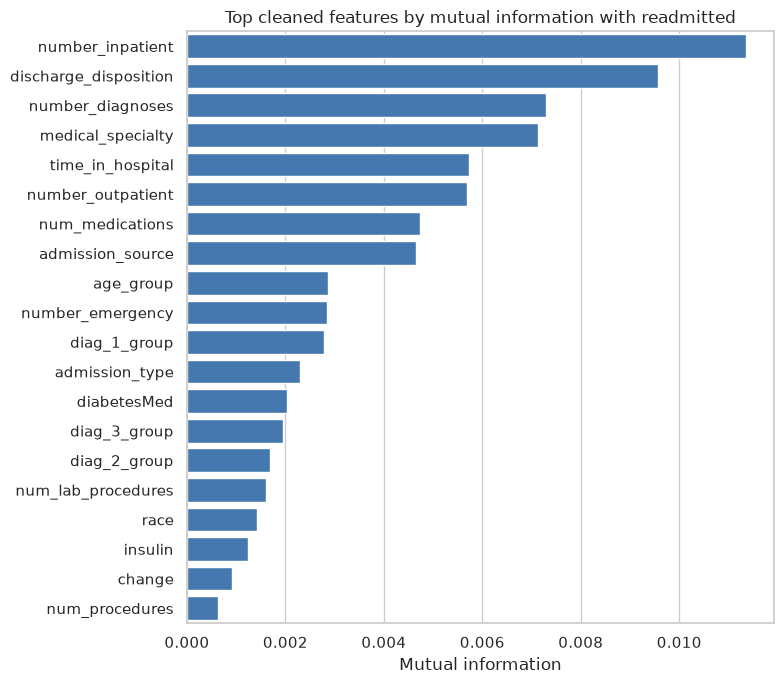

In [13]:
def _as_mi_matrix(train_df, columns):
    """Build a mixed numeric/categorical matrix for mutual information scoring."""
    parts = []
    discrete_mask = []

    for col in columns:
        series = train_df[col]
        if pd.api.types.is_numeric_dtype(series):
            numeric = pd.to_numeric(series, errors="coerce")
            fill_value = numeric.median()
            if pd.isna(fill_value):
                fill_value = 0
            parts.append(numeric.fillna(fill_value).to_frame(col))
            discrete_mask.append(False)
        else:
            values = series.astype("object").where(series.notna(), "Missing").astype(str).to_frame(col)
            enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
            encoded = pd.DataFrame(enc.fit_transform(values), columns=[col], index=train_df.index)
            parts.append(encoded)
            discrete_mask.append(True)

    return pd.concat(parts, axis=1), np.array(discrete_mask, dtype=bool)


def rank_raw_features(train_df, columns, target=TARGET, random_state=RANDOM_STATE):
    X_mi, discrete_mask = _as_mi_matrix(train_df, columns)
    y = train_df[target].astype(str)
    mi = mutual_info_classif(
        X_mi,
        y,
        discrete_features=discrete_mask,
        random_state=random_state,
    )
    out = pd.DataFrame({"feature": columns, "mutual_information": mi})
    out["n_unique_train"] = [train_df[col].nunique(dropna=False) for col in columns]
    out["dtype"] = [str(train_df[col].dtype) for col in columns]
    return out.sort_values("mutual_information", ascending=False).reset_index(drop=True)


def select_diverse_features(train_df, ranked_features, max_features=30, redundancy_threshold=0.90):
    """Greedy mRMR-style filter using normalized MI between raw string columns."""
    selected = []
    encoded_cache = {}

    def encoded(col):
        if col not in encoded_cache:
            values = train_df[col].astype("object").where(train_df[col].notna(), "Missing").astype(str)
            encoded_cache[col] = pd.factorize(values, sort=True)[0]
        return encoded_cache[col]

    for feature in ranked_features:
        if len(selected) >= max_features:
            break
        redundant = False
        for chosen in selected:
            redundancy = normalized_mutual_info_score(encoded(feature), encoded(chosen))
            if redundancy >= redundancy_threshold:
                redundant = True
                break
        if not redundant:
            selected.append(feature)
    return selected


mi_scores = rank_raw_features(train_raw, feature_candidates)
display(mi_scores.head(25))

MAX_RANKED_FEATURES = 30
ranked_feature_pool = select_diverse_features(
    train_raw,
    mi_scores["feature"].tolist(),
    max_features=MAX_RANKED_FEATURES,
    redundancy_threshold=0.90,
)

print(f"Selected diverse cleaned feature pool ({len(ranked_feature_pool)} features):")
print(ranked_feature_pool)

plt.figure(figsize=(8, 7))
sns.barplot(
    data=mi_scores.head(20),
    y="feature",
    x="mutual_information",
    color="#3478bf",
)
plt.title("Top cleaned features by mutual information with readmitted")
plt.xlabel("Mutual information")
plt.ylabel("")
plt.tight_layout()

## Minimal Cleaned-to-Discrete Preparation

`pgmpy` Bayesian Networks are discrete, so every selected feature must still become a finite set of states — the same requirement as in the raw-feature notebook. The class below is unchanged from that notebook: it learns numeric bin edges and top categories from the training split only, maps unseen validation/test categories to `Other`, and turns missing values into an explicit `Missing` state. The difference is what it now operates on: cleaned, clinically meaningful columns (e.g. `diag_1_group` with 9 states) instead of raw high-cardinality columns (e.g. `diag_1` with hundreds of ICD-9 codes).

In [14]:
class CleanedDiscretePreprocessor:
    def __init__(self, features, target=TARGET, numeric_bins=4, max_categories=12):
        self.features = list(features)
        self.target = target
        self.numeric_bins = numeric_bins
        self.max_categories = max_categories
        self.numeric_bin_edges_ = {}
        self.numeric_labels_ = {}
        self.category_levels_ = {}
        self.numeric_as_category_ = set()

    def fit(self, df):
        for col in self.features:
            series = df[col]
            if pd.api.types.is_numeric_dtype(series) and series.nunique(dropna=True) > self.numeric_bins:
                values = pd.to_numeric(series, errors="coerce").dropna()
                if values.nunique() > 1:
                    _, edges = pd.qcut(
                        values,
                        q=min(self.numeric_bins, values.nunique()),
                        retbins=True,
                        duplicates="drop",
                    )
                    edges = np.unique(edges)
                    if len(edges) > 2:
                        edges[0] = -np.inf
                        edges[-1] = np.inf
                        self.numeric_bin_edges_[col] = edges
                        self.numeric_labels_[col] = [f"Bin_{i}" for i in range(1, len(edges))]
                        continue
            self.numeric_as_category_.add(col)
            self.category_levels_[col] = self._top_categories(series)
        return self

    def _top_categories(self, series):
        values = series.astype("object").where(series.notna(), "Missing").astype(str)
        top_n = max(self.max_categories - 2, 1)  # leave room for Other/Missing
        return values.value_counts().head(top_n).index.tolist()

    def _transform_feature(self, df, col):
        series = df[col]
        if col in self.numeric_bin_edges_:
            values = pd.to_numeric(series, errors="coerce")
            out = pd.cut(
                values,
                bins=self.numeric_bin_edges_[col],
                labels=self.numeric_labels_[col],
                include_lowest=True,
            ).astype("object")
            return out.where(out.notna(), "Missing").astype(str)

        values = series.astype("object").where(series.notna(), "Missing").astype(str)
        known = set(self.category_levels_[col]) | {"Missing", "Other"}
        return values.where(values.isin(known), "Other").astype(str)

    def transform(self, df):
        out = pd.DataFrame(index=df.index)
        for col in self.features:
            out[col] = self._transform_feature(df, col)
        out[self.target] = df[self.target].astype("object").where(df[self.target].notna(), "Missing").astype(str)
        return out.reset_index(drop=True)

    def fit_transform(self, df):
        return self.fit(df).transform(df)


def stratified_sample(df, n_samples, target=TARGET, random_state=RANDOM_STATE):
    if n_samples is None or n_samples >= len(df):
        return df.reset_index(drop=True)
    sample, _ = train_test_split(
        df,
        train_size=n_samples,
        stratify=df[target],
        random_state=random_state,
    )
    return sample.reset_index(drop=True)

## Hill-Climb Bayesian Network Helpers

Unchanged from the raw-feature notebook: hill climb learns the graph structure over the cleaned/discretized columns, and Bayesian parameter estimation with a BDeu prior smooths the conditional probability tables so rare states are less brittle.

In [15]:
def get_bn_class():
    try:
        from pgmpy.models import DiscreteBayesianNetwork
        return DiscreteBayesianNetwork
    except ImportError:
        from pgmpy.models import BayesianNetwork
        return BayesianNetwork


def make_structure_score(data, score_name):
    score_name = score_name.lower()
    if score_name == "bic":
        try:
            from pgmpy.estimators import BicScore
            return BicScore(data)
        except ImportError:
            from pgmpy.estimators import BIC
            return BIC(data)
    if score_name == "k2":
        try:
            from pgmpy.estimators import K2Score
            return K2Score(data)
        except ImportError:
            from pgmpy.estimators import K2
            return K2(data)
    if score_name == "bdeu":
        try:
            from pgmpy.estimators import BDeuScore
            return BDeuScore(data, equivalent_sample_size=10)
        except ImportError:
            from pgmpy.estimators import BDeu
            return BDeu(data, equivalent_sample_size=10)
    raise ValueError(f"Unknown score_name: {score_name}")


def learn_structure_hill_climb(structure_df, score_name="bic", max_indegree=3, tabu_length=100):
    structure_df = structure_df.astype(str)
    score_name = score_name.lower()

    # pgmpy >= 1.0 introduced a causal_discovery hill-climb API.
    # It currently maps most directly to discrete BIC scoring.
    if score_name == "bic":
        try:
            from pgmpy.causal_discovery import HillClimbSearch as CausalHillClimbSearch
            hc = CausalHillClimbSearch(
                scoring_method="bic-d",
                return_type="dag",
                max_indegree=max_indegree,
                show_progress=False,
            )
            hc.fit(structure_df)
            graph = getattr(hc, "causal_graph_", None)
            if graph is not None:
                return list(graph.edges())
        except Exception:
            pass

    from pgmpy.estimators import HillClimbSearch

    hc = HillClimbSearch(structure_df)
    score = make_structure_score(structure_df, score_name)
    dag = hc.estimate(
        scoring_method=score,
        max_indegree=max_indegree,
        tabu_length=tabu_length,
        show_progress=False,
    )
    return list(dag.edges())


def fit_bn_model(train_df, edges, equivalent_sample_size=10):
    from pgmpy.estimators import BayesianEstimator

    train_df = train_df.astype(str)
    BNClass = get_bn_class()
    model = BNClass()
    model.add_nodes_from(train_df.columns)
    model.add_edges_from(edges)

    # Colab/pgmpy versions differ in what model.fit forwards to BayesianEstimator.
    # Build and attach CPDs directly so BDeu smoothing works across versions.
    estimator = BayesianEstimator(model, train_df)
    cpds = estimator.get_parameters(
        prior_type="BDeu",
        equivalent_sample_size=equivalent_sample_size,
    )
    model.add_cpds(*cpds)
    model.check_model()
    return model


def train_bn_pipeline(
    raw_train_df,
    features,
    score_name="bic",
    max_indegree=3,
    max_categories=12,
    numeric_bins=4,
    structure_sample_size=15_000,
    equivalent_sample_size=10,
):
    preprocessor = CleanedDiscretePreprocessor(
        features,
        numeric_bins=numeric_bins,
        max_categories=max_categories,
    )
    train_bn_df = preprocessor.fit_transform(raw_train_df)
    structure_df = stratified_sample(train_bn_df, structure_sample_size)
    edges = learn_structure_hill_climb(
        structure_df,
        score_name=score_name,
        max_indegree=max_indegree,
    )
    model = fit_bn_model(
        train_bn_df,
        edges,
        equivalent_sample_size=equivalent_sample_size,
    )
    return model, preprocessor, train_bn_df, edges


def plot_bn_structure(model, title="Learned Bayesian Network"):
    graph = nx.DiGraph()
    graph.add_nodes_from(model.nodes())
    graph.add_edges_from(model.edges())

    plt.figure(figsize=(12, 8))
    pos = nx.spring_layout(graph, seed=RANDOM_STATE, k=0.9)
    colors = ["#e15759" if node == TARGET else "#4e79a7" for node in graph.nodes()]
    nx.draw_networkx_nodes(graph, pos, node_color=colors, node_size=1600, alpha=0.95)
    nx.draw_networkx_edges(graph, pos, arrows=True, arrowstyle="-|>", arrowsize=18, width=1.4)
    nx.draw_networkx_labels(graph, pos, font_size=9, font_color="white")
    plt.title(title)
    plt.axis("off")
    plt.tight_layout()

In [16]:
def predict_bn_probabilities(model, bn_df, target=TARGET, batch_size=1_000):
    labels = list(model.get_cpds(target).state_names[target])
    feature_cols = [col for col in bn_df.columns if col != target]
    frames = []

    for start in range(0, len(bn_df), batch_size):
        batch = bn_df.iloc[start:start + batch_size]
        pred = model.predict_probability(batch[feature_cols])

        if target in pred.columns:
            arr = np.vstack(pred[target].to_numpy())
            frame = pd.DataFrame(arr, columns=labels, index=batch.index)
        else:
            expected = [f"{target}_{label}" for label in labels]
            frame = pred.reindex(columns=expected, fill_value=0.0).copy()
            frame.columns = labels
        frames.append(frame.astype(float))

    prob_df = pd.concat(frames).sort_index()
    row_sums = prob_df.sum(axis=1).replace(0, np.nan)
    prob_df = prob_df.div(row_sums, axis=0).fillna(1 / len(labels))
    return prob_df[labels]


def evaluate_bn_model(model, preprocessor, raw_eval_df, target=TARGET, name="model"):
    eval_bn_df = preprocessor.transform(raw_eval_df)
    y_true = eval_bn_df[target].astype(str).to_numpy()
    prob_df = predict_bn_probabilities(model, eval_bn_df, target=target)
    labels = prob_df.columns.tolist()
    y_pred = prob_df.idxmax(axis=1).to_numpy()

    metrics = {
        "model": name,
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "macro_precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "log_loss": log_loss(y_true, prob_df.to_numpy(), labels=labels),
        "brier_multiclass": np.mean(
            np.sum((pd.get_dummies(pd.Categorical(y_true, categories=labels)).to_numpy() - prob_df.to_numpy()) ** 2, axis=1)
        ),
        "n_edges": len(model.edges()),
        "max_parents": max((len(list(model.predecessors(node))) for node in model.nodes()), default=0),
    }

    try:
        y_binary = label_binarize(y_true, classes=labels)
        metrics["roc_auc_ovr_macro"] = roc_auc_score(y_binary, prob_df.to_numpy(), average="macro", multi_class="ovr")
        metrics["pr_auc_macro"] = average_precision_score(y_binary, prob_df.to_numpy(), average="macro")
    except ValueError:
        metrics["roc_auc_ovr_macro"] = np.nan
        metrics["pr_auc_macro"] = np.nan

    return metrics, y_true, y_pred, prob_df


def evaluate_majority_baseline(train_df, eval_df, target=TARGET):
    clf = DummyClassifier(strategy="most_frequent")
    clf.fit(np.zeros((len(train_df), 1)), train_df[target].astype(str))
    y_true = eval_df[target].astype(str).to_numpy()
    y_pred = clf.predict(np.zeros((len(eval_df), 1)))
    return {
        "model": "majority_baseline",
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "macro_precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "log_loss": np.nan,
        "brier_multiclass": np.nan,
        "roc_auc_ovr_macro": np.nan,
        "pr_auc_macro": np.nan,
        "n_edges": 0,
        "max_parents": 0,
    }


def show_classification_outputs(y_true, y_pred, labels, title="Confusion matrix"):
    print(classification_report(y_true, y_pred, labels=labels, zero_division=0))
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()

## Applying the Best Configuration From the Raw-Feature Grid Search

The raw-feature notebook ran an exhaustive grid over feature count (`8/12/16`), structure score (`bic/k2`), max in-degree (`2/3`), category cap (`8/12`), and numeric bin count (`4`) — 24 candidate Bayesian Networks in total, selected by validation `macro_f1` with `log_loss` as a tie-breaker. The winning configuration was:

| n_features | score | max_indegree | max_categories | numeric_bins | val macro_f1 | val log_loss |
|---|---|---|---|---|---|---|
| 12 | k2 | 3 | 8 | 4 | 0.3506 | 0.9160 |

Rather than repeating that full 24-run grid search here, we **apply that exact configuration directly** to the cleaned dataset. The only thing that necessarily changes is *which* 12 features are selected, since cleaning replaced/renamed/merged several raw columns (e.g. `diag_1` → `diag_1_group`, `discharge_disposition_id` → `discharge_disposition`); the ranking + diversity filter above is re-run on the cleaned columns, and the top 12 from that ranked pool are used, exactly as the raw notebook would have done for `n_features=12`.

In [17]:
BEST_CONFIG = dict(
    score_name="k2",
    max_indegree=3,
    max_categories=8,
    numeric_bins=4,
)
BEST_N_FEATURES = 12
STRUCTURE_SAMPLE_SIZE = 15_000
EQUIVALENT_SAMPLE_SIZE = 10

best_features = ranked_feature_pool[:BEST_N_FEATURES]
print(f"Applying best configuration ({BEST_N_FEATURES} features, {BEST_CONFIG}):")
print(best_features)

model, preprocessor, train_bn_df, edges = train_bn_pipeline(
    train_raw,
    features=best_features,
    structure_sample_size=STRUCTURE_SAMPLE_SIZE,
    equivalent_sample_size=EQUIVALENT_SAMPLE_SIZE,
    **BEST_CONFIG,
)

val_metrics, _, _, _ = evaluate_bn_model(model, preprocessor, val_raw, name="cleaned_best_config")
baseline_val_metrics = evaluate_majority_baseline(train_raw, val_raw)

validation_table = pd.DataFrame([baseline_val_metrics, val_metrics])
display(validation_table.reindex(columns=[
    "model", "accuracy", "balanced_accuracy", "macro_f1", "weighted_f1",
    "log_loss", "roc_auc_ovr_macro", "pr_auc_macro", "n_edges", "max_parents",
]))

Applying best configuration (12 features, {'score_name': 'k2', 'max_indegree': 3, 'max_categories': 8, 'numeric_bins': 4}):
['number_inpatient', 'discharge_disposition', 'number_diagnoses', 'medical_specialty', 'time_in_hospital', 'number_outpatient', 'num_medications', 'admission_source', 'age_group', 'number_emergency', 'diag_1_group', 'admission_type']


,model,accuracy,balanced_accuracy,macro_f1,weighted_f1,log_loss,roc_auc_ovr_macro,pr_auc_macro,n_edges,max_parents
0,majority_baseline,0.592606,0.333333,0.248065,0.441015,NaN,NaN,NaN,0,0
1,cleaned_best_config,0.599214,0.354239,0.306285,0.491827,0.874833,0.592654,0.388291,29,3


**Reading the validation numbers:** cleaning changes the class balance of the problem itself — after keeping one encounter per patient and removing hospice/death discharges, the majority class (`NO`) grows from 53.9% to about 59.3% of encounters, so accuracy is not directly comparable between the raw and cleaned notebooks. `macro_f1` is comparable in spirit (both notebooks pick it as the primary metric) but is expected to be somewhat lower here: grouping `diag_1`/`diag_2`/`diag_3` into 9 clinical categories removes some of the raw mutual information that fine-grained ICD-9 codes carried (the raw notebook's top-ranked features were the un-grouped diagnosis codes). This is the expected trade-off of the cleaning stage — less raw signal from an over-fit-prone, hard-to-interpret 700+ category feature, in exchange for a smaller, clinically interpretable, and more robust conditional probability table. The comparison against the majority-class baseline on the same split is the fairer way to judge whether the network is still learning something useful.

## Final Model and Held-Out Test Metrics

Retrain the best configuration on `train + validation`, then evaluate once on the untouched `test` split.

,model,accuracy,balanced_accuracy,macro_f1,weighted_f1,macro_precision,macro_recall,log_loss,roc_auc_ovr_macro,pr_auc_macro,brier_multiclass,n_edges,max_parents
0,majority_baseline,0.592656,0.333333,0.248079,0.441076,0.197552,0.333333,NaN,NaN,NaN,NaN,0,0
1,final_bn_cleaned,0.604015,0.358084,0.311553,0.497749,0.477769,0.358084,0.873657,0.589917,0.389063,0.52693,29,3


              precision    recall  f1-score   support

         <30       0.31      0.01      0.02      1257
         >30       0.51      0.10      0.16      4445
          NO       0.61      0.96      0.75      8296

    accuracy                           0.60     13998
   macro avg       0.48      0.36      0.31     13998
weighted avg       0.55      0.60      0.50     13998



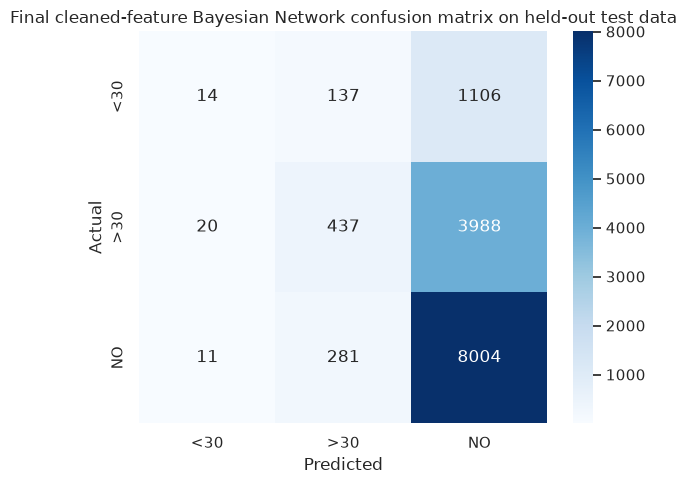

In [18]:
final_model, final_preprocessor, final_train_bn_df, final_edges = train_bn_pipeline(
    trainval_raw,
    features=best_features,
    structure_sample_size=STRUCTURE_SAMPLE_SIZE,
    equivalent_sample_size=EQUIVALENT_SAMPLE_SIZE,
    **BEST_CONFIG,
)

test_metrics, y_test, y_test_pred, test_probabilities = evaluate_bn_model(
    final_model,
    final_preprocessor,
    test_raw,
    name="final_bn_cleaned",
)

baseline_test_metrics = evaluate_majority_baseline(trainval_raw, test_raw)
final_metric_table = pd.DataFrame([baseline_test_metrics, test_metrics])
display(final_metric_table.reindex(columns=[
    "model", "accuracy", "balanced_accuracy", "macro_f1", "weighted_f1",
    "macro_precision", "macro_recall", "log_loss", "roc_auc_ovr_macro",
    "pr_auc_macro", "brier_multiclass", "n_edges", "max_parents",
]))

labels = test_probabilities.columns.tolist()
show_classification_outputs(
    y_test,
    y_test_pred,
    labels=labels,
    title="Final cleaned-feature Bayesian Network confusion matrix on held-out test data",
)

## Inspect Learned Relations and Probabilities

The structure plot shows the relations discovered by hill climb over the cleaned features. The probability table lets you inspect calibrated class probabilities for individual held-out patients.

Learned 29 edges


,parent,child
0,number_inpatient,readmitted
1,number_inpatient,number_outpatient
2,number_inpatient,diag_1_group
3,number_inpatient,time_in_hospital
4,discharge_disposition,time_in_hospital
5,discharge_disposition,readmitted
6,number_diagnoses,admission_source
7,time_in_hospital,num_medications
8,num_medications,number_diagnoses
9,admission_source,medical_specialty


,encounter_id,patient_nbr,number_inpatient,discharge_disposition,number_diagnoses,medical_specialty,time_in_hospital,number_outpatient,num_medications,admission_source,age_group,number_emergency,diag_1_group,admission_type,readmitted,predicted_readmitted,prob_<30,prob_>30,prob_NO
0,225751584,86180823,0,Transferred to SNF,9,Emergency/Trauma,10,0,27,Emergency room,>60,0,Respiratory,Emergency,>30,NO,0.125677,0.294266,0.580056
1,120692106,54913275,0,Discharged to home,7,Gastroenterology,3,0,8,Emergency room,>60,0,Digestive,Emergency,<30,NO,0.060608,0.288811,0.650580
2,195686688,41145408,0,Discharged to home,5,Missing,3,0,13,Emergency room,>60,0,Genitourinary,Emergency,>30,NO,0.060608,0.288811,0.650580
3,122996124,91151838,0,Transferred to ICF,9,Emergency/Trauma,4,0,11,Emergency room,>60,0,Other,Urgent,>30,NO,0.139252,0.261659,0.599088
4,227615940,97070328,0,Discharged to home,9,Missing,2,0,15,Physician referral,30-60,0,Circulatory,Elective,NO,NO,0.060608,0.288811,0.650580
5,110758176,24399594,0,Discharged to home,7,Nephrology,2,0,6,Physician referral,>60,0,Genitourinary,Urgent,>30,NO,0.060608,0.288811,0.650580
6,139590282,35555634,5,Discharged to home,9,Missing,3,0,20,Emergency room,30-60,0,Digestive,Emergency,<30,>30,0.240109,0.519783,0.240109
7,134031516,105001821,0,Transferred to SNF,9,Family/GeneralPractice,3,0,9,Emergency room,30-60,0,Other,Elective,NO,NO,0.125677,0.294266,0.580056
8,140946948,25133301,0,Discharged to home,5,Cardiology,1,0,6,Physician referral,>60,0,Circulatory,Elective,>30,NO,0.060608,0.288811,0.650580
9,162322572,58534272,1,Home with home health service,9,Oncology,11,0,22,Physician referral,>60,0,Other,Urgent,<30,>30,0.092017,0.466058,0.441926


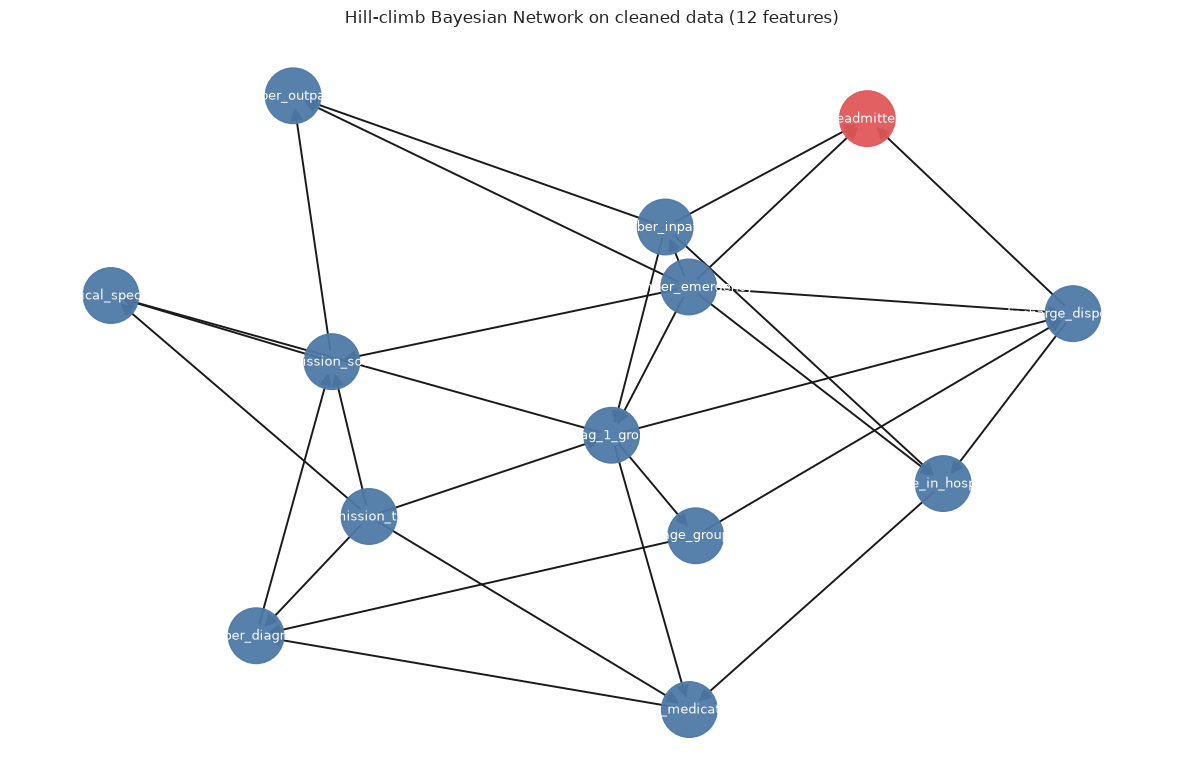

In [19]:
edge_table = pd.DataFrame(final_model.edges(), columns=["parent", "child"])
print(f"Learned {len(edge_table)} edges")
display(edge_table)

plot_bn_structure(
    final_model,
    title=f"Hill-climb Bayesian Network on cleaned data ({len(best_features)} features)",
)

sample_view = test_raw[[col for col in ID_COLUMNS if col in test_raw.columns] + best_features + [TARGET]].reset_index(drop=True)
prob_view = test_probabilities.add_prefix("prob_").reset_index(drop=True)
pred_view = pd.DataFrame({"predicted_readmitted": y_test_pred})

display(pd.concat([sample_view, pred_view, prob_view], axis=1).head(20))

## Optional Export

Run this if you want to download the trained model bundle. It includes the pgmpy model, selected cleaned features, and the preprocessing object needed to prepare new raw rows (cleaned the same way) for prediction.

In [20]:
MODEL_BUNDLE_DIR = Path("/content") if Path("/content").exists() else Path(".")
MODEL_BUNDLE_PATH = str(MODEL_BUNDLE_DIR / "cleaned_hill_climb_bn_model.pkl")

model_bundle = {
    "model": final_model,
    "preprocessor": final_preprocessor,
    "features": best_features,
    "target": TARGET,
    "best_config": BEST_CONFIG,
    "val_metrics": val_metrics,
    "test_metrics": test_metrics,
}

joblib.dump(model_bundle, MODEL_BUNDLE_PATH)
print(f"Saved model bundle to {MODEL_BUNDLE_PATH}")

try:
    from google.colab import files
    files.download(MODEL_BUNDLE_PATH)
except Exception:
    print("Not running in Colab or download unavailable. The file was still saved locally.")

Saved model bundle to cleaned_hill_climb_bn_model.pkl
Not running in Colab or download unavailable. The file was still saved locally.
